## 사전학습 모델

- ResNet18 사용

In [ ]:
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim

import requests
from PIL import Image
from io import BytesIO
import os
import random
import shutil

# 사전학습 모델 라이브러리 추가
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

# pip install icrawler
from icrawler.builtin import BingImageCrawler, BaiduImageCrawler

In [ ]:
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))

2.12.0+cu130
True
13.0
NVIDIA GeForce RTX 5060


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

### 2. ResNet18 사전학습 모델 로드

- 모델 다운로드 위치 변경가능

In [44]:
os.environ['TORCH_HOME'] = './cust_models'

In [45]:
# 사전학습 가중치 선택
weight = ResNet18_Weights.DEFAULT

# 사전학습 모델 불러오기
model = resnet18(weights=weight)

In [46]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

### 3. 전처리 가져오기

- 직접구상했던 transform을 자동구성

In [47]:
preprocess = weight.transforms()
preprocess

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

### 4. 샘플이미지 예측

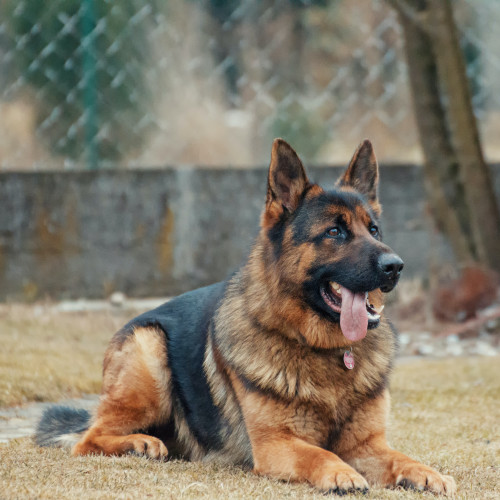

In [48]:
url = 'https://raw.githubusercontent.com/pytorch/vision/main/gallery/assets/dog2.jpg'

response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert('RGB')
img

In [49]:
input_tensor = preprocess(img)
input_tensor

tensor([[[-0.8849, -0.9192, -1.0048,  ..., -0.3883, -0.2856, -0.2171],
         [-1.0904, -1.1418, -1.2617,  ..., -0.4911, -0.3027, -0.1828],
         [-1.2445, -1.3302, -1.4329,  ..., -0.5596, -0.3883, -0.2513],
         ...,
         [ 1.2214,  1.2899,  1.2557,  ...,  1.2728,  1.2728,  1.3413],
         [ 1.3413,  1.2043,  0.9474,  ...,  1.3927,  1.4098,  1.3413],
         [ 0.9646,  1.1015,  0.9474,  ...,  1.4098,  1.4098,  1.3413]],

        [[-0.3200, -0.2675, -0.3725,  ..., -0.1275,  0.0476,  0.1527],
         [-0.5826, -0.5826, -0.7227,  ..., -0.2325,  0.0126,  0.1702],
         [-0.7752, -0.8452, -0.9153,  ..., -0.2850, -0.0399,  0.1352],
         ...,
         [ 1.1331,  1.1856,  1.1506,  ...,  1.1856,  1.0980,  1.0805],
         [ 1.2556,  1.0630,  0.7129,  ...,  1.3256,  1.2381,  1.1155],
         [ 0.8354,  0.9055,  0.7129,  ...,  1.3782,  1.3606,  1.2381]],

        [[-0.1312, -0.0615, -0.1661,  ..., -0.0092,  0.1825,  0.3219],
         [-0.3927, -0.3927, -0.5495,  ..., -0

In [50]:
input_batch = input_tensor.unsqueeze(0) # 차원 추가
input_batch.shape

torch.Size([1, 3, 224, 224])

In [51]:
# 예측
model.eval() 
model = model.to(device)
input_batch = input_batch.to(device)

with torch.no_grad():
    output = model(input_batch)

output.shape  # torch.Size([1, 1000]) => 1000개 클래스 중 하나를 예측

torch.Size([1, 1000])

### 5. 예측결과확인

In [52]:
prob = torch.softmax(output[0], dim=0)

top5_prob, top5_catid = torch.topk(prob, 5)

categories = weight.meta['categories']

for i in range(5):
    print(categories[top5_catid[i]], top5_prob[i].item())

German shepherd 0.9968082308769226
malinois 0.0015053615206852555
Norwegian elkhound 0.0006996517186053097
Leonberg 0.00041095231426879764
Tibetan mastiff 0.0001649117039050907


### 6. 이미지 다운로드

- dataset/train과 test 폴더 아래
    - dog
    - cat
    - bird

- icrawler.BingImageCrawler 사용 이미지 다운로드

In [53]:
raw_dir = 'raw'
dataset_dir = 'dataset'

classes = {
    'dog photo': 'dog',
    'cat photo': 'cat',
    'bird photo': 'bird'
}

num_classes = 3
batch_size = 16
num_epoch = 5
lr = 0.001

In [54]:
# 학습이미지 폴더
# 반복 다운로드 가능
for keyword, class_name in classes.items():
    save_dir = os.path.join(dataset_dir, class_name)
    # print(save_dir)
    os.makedirs(save_dir, exist_ok=True)

    crawler = BingImageCrawler(
        storage={'root_dir': save_dir}
    )

    crawler.crawl(
        keyword=keyword,
        max_num=150
    )

2026-05-21 16:04:36,851 - INFO - icrawler.crawler - start crawling...
2026-05-21 16:04:36,853 - INFO - icrawler.crawler - starting 1 feeder threads...
2026-05-21 16:04:36,854 - INFO - icrawler.crawler - starting 1 parser threads...
2026-05-21 16:04:36,854 - INFO - icrawler.crawler - starting 1 downloader threads...
2026-05-21 16:04:37,331 - INFO - parser - parsing result page https://www.bing.com/images/async?q=dog photo&first=0
2026-05-21 16:04:37,343 - INFO - downloader - skip downloading file 000001.jpg
2026-05-21 16:04:37,346 - INFO - downloader - skip downloading file 000002.jpg
2026-05-21 16:04:37,347 - INFO - downloader - skip downloading file 000003.jpg
2026-05-21 16:04:37,348 - INFO - downloader - skip downloading file 000004.jpg
2026-05-21 16:04:37,348 - INFO - downloader - skip downloading file 000005.jpg
2026-05-21 16:04:37,349 - INFO - downloader - skip downloading file 000006.jpg
2026-05-21 16:04:37,350 - INFO - downloader - skip downloading file 000007.jpg
2026-05-21 16:

2026-05-21 16:05:08,349 - INFO - parser - parsing result page https://www.bing.com/images/async?q=bird photo&first=140
2026-05-21 16:05:10,563 - INFO - parser - no more page urls for thread parser-001 to parse
2026-05-21 16:05:10,564 - INFO - parser - thread parser-001 exit


In [ ]:
# 테스트이미지 폴더
# 반복 다운로드 가능
for keyword, class_name in classes.items():
    save_dir = os.path.join(testset_dir, class_name)
    # print(save_dir)
    os.makedirs(save_dir, exist_ok=True)

    # BingImageCrawler
    crawler = BaiduImageCrawler(
        storage={'root_dir': save_dir}
    )

    crawler.crawl(
        keyword=keyword,
        max_num=150
    )

### 7. 커스텀데이터셋용 FC 변경

- 1000개 클래스에서 3개로 변경

In [32]:

model.fc

Linear(in_features=512, out_features=1000, bias=True)

In [55]:
# 분류를 3가지만 할 예정
num_classes = 3

model.fc = nn.Linear(
    in_features=model.fc.in_features,
    out_features=num_classes
)

model = model.to(device)
model.fc

Linear(in_features=512, out_features=3, bias=True)

### 8. 재학습용 설정
- fc층 파라미터 재학습설정
- 옵티마이저 설정

In [56]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

In [57]:
loss_fn = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

### 9. 데이터셋 불러오기

- dataset/train 폴더 내 데이터셋 로드

In [59]:
train_dataset = ImageFolder(
    root=dataset_dir,
    transform=preprocess
)
test_dataset = ImageFolder(
    root=testset_dir,
    transform=preprocess
)
print(train_dataset, test_dataset)

NameError: name 'testset_dir' is not defined

In [ ]:
train_dataset.classes, test_dataset.classes

['bird', 'cat', 'dog']

In [ ]:
train_dataset.class_to_idx, test_dataset.class_to_idx

{'bird': 0, 'cat': 1, 'dog': 2}

### 10. 데이터로더 변환

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True    
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print(f'train 데이터로더 개수 : {len(train_loader)}')  # ??
print(f'test 데이터로더 개수 : {len(test_loader)}')

NameError: name 'test_dataset' is not defined

### 11 이미지 배치 확인

In [ ]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

### 12. 학습

In [24]:
model = model.to(device)

In [60]:
for epoch in range(num_epoch):
    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_fn(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)

    avg_loss = train_loss / len(train_loader)
    accuracy = train_correct / train_total

    print(f'Epoch [{epoch+1:2d}/{num_epoch:2d}]')
    print(f'Train Loss : {train_loss:.4f}')
    print(f'Train Acc : {accuracy:.4f}')
    print(f'Avg Loss : {avg_loss:.4f}')

Epoch [ 1/ 5]
Train Loss : 7.2814
Train Acc : 0.5952
Avg Loss : 0.9102
Epoch [ 2/ 5]
Train Loss : 4.1280
Train Acc : 0.7857
Avg Loss : 0.5160
Epoch [ 3/ 5]
Train Loss : 2.3133
Train Acc : 0.9762
Avg Loss : 0.2892
Epoch [ 4/ 5]
Train Loss : 1.6501
Train Acc : 0.9762
Avg Loss : 0.2063
Epoch [ 5/ 5]
Train Loss : 0.9577
Train Acc : 1.0000
Avg Loss : 0.1197


### 13. 테스트 데이터셋 평가

In [61]:
model.eval()

test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predict = torch.max(outputs, 1)

        test_correct += (predict == labels).sum().item()
        test_total += labels.size(0)

test_acc = test_correct / test_total
print(f'테스트 정확도 : {test_acc:.4f}')

NameError: name 'test_loader' is not defined

### 14. 웹크롤링으로 이미지 크롤링 다운로드

In [ ]:
keywords = [
    'golden retriever dog',
    'labrador dog',
    'husky dog',
    'poodle dog',
    'bulldog dog',
    'puppy dog',
    'small dog',
    'big dog',
    'cute dog',
    'black dog',
    'white dog',
    'brown dog',
    'running dog',
    'dog face',
    'dog outdoors',
    'dog sitting',
    'dog playing',
    'pet dog',
    'domestic dog',
    'happy dog',
    'sleeping dog',
    'dog portrait',
    'street dog',
    'dog on grass',
    'family dog'
]

# 0, 'golden retriever dog'
# 1, 'labrador dog'
for idx, keyword in enumerate(keywords):

    temp_dir = f'dataset/test/dog/temp_{idx}'
    os.makedirs(temp_dir, exist_ok=True)

    ## BindImageCrawler 보다 BaiduImageCrawler 가 훨씬 강력
    crawler = BaiduImageCrawler(
        storage={'root_dir': temp_dir}
    )

    crawler.crawl(
        keyword=keyword,
        max_num=30
    )

print('Done!')

### 15. 테스트 이미지 시각화

In [ ]:
import matplotlib.pyplot as plt

images, labels = next(iter(test_loader))

image = images[15]
label = labels[15]

input_batch = image.unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    output = model(input_batch)
    pred = torch.argmax(output, 1).item()

image_np = image.permute(1, 2, 0).numpy()

plt.imshow(image_np)
plt.title(f'True : {test_dataset.classes[label]} / Pred : {test_dataset.classes[pred]}')
plt.axis('off')
plt.show()

### 16. 모델 저장

In [ ]:
torch.save(
    model.state_dict(),
    'resnet18_bird_cat_dog.pth'
)